# Kaggle House Prices — Complete Pipeline

Notebook sạch theo `GUIDE_HANDSON_NOTEBOOK.md`.

**Metric:** RMSLE (càng thấp càng tốt)  
**Mục tiêu cuối:** `submission.csv` (`Id`, `SalePrice`)

| Phase | Nội dung | Status |
|------:|----------|--------|
| 0 | Setup & hiểu bài toán | done |
| 1 | Load data sạch | done |
| 2 | EDA | done |
| 3 | Missing / cleaning | done |
| 4 | Feature engineering | done |
| 5 | Encoding & scaling | done |
| 6 | Model + validation (CV / RMSLE) | done |
| 7 | Predict test + submission | **đang làm** |
| 8 | Error analysis (optional) | pending |

> Kernel khuyến nghị: **Python (.venv House Prices)**

## 0. Setup & imports

Kiểm tra đang chạy đúng `.venv` của project trước khi load data.

In [24]:
import sys
from pathlib import Path

print("Python:", sys.version.split()[0])
print("Executable:", sys.executable)

assert ".venv" in sys.executable.replace("\\", "/"), (
    "Sai kernel! Chọn kernel Python (.venv House Prices) hoặc .venv/bin/python"
)

Python: 3.12.0
Executable: /Users/fuwhis/Downloads/VEF_DA_FinalProject/.venv/bin/python


In [25]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import norm, probplot

from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path(".")
print("Imports OK")

Imports OK


## 1. Load data

- Load **local** `train.csv` / `test.csv` (không wget URL GitHub `/blob/`).
- Giữ `test_ids` trước khi xử lý.
- Tách target `y`; không để `SalePrice` lẫn vào feature của test.

In [26]:
train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"

assert train_path.exists(), f"Không thấy {train_path.resolve()}"
assert test_path.exists(), f"Không thấy {test_path.resolve()}"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("train:", train.shape)
print("test :", test.shape)

assert train.shape == (1460, 81), f"train shape lệch: {train.shape}"
assert test.shape == (1459, 80), f"test shape lệch: {test.shape}"
assert "SalePrice" in train.columns
assert "SalePrice" not in test.columns

train: (1460, 81)
test : (1459, 80)


In [27]:
# Giữ Id của test để submission sau này
test_ids = test["Id"].copy()

# Target (thang gốc). Modeling sẽ dùng log1p ở Phase 2/6.
y = train["SalePrice"].copy()

# Feature matrix: cùng cột giữa train/test (bỏ SalePrice khỏi train features)
X_train_raw = train.drop(columns=["SalePrice"]).copy()
X_test_raw = test.copy()

print("test_ids:", len(test_ids), "| range:", test_ids.min(), "→", test_ids.max())
print("y describe:")
display(y.describe())
print("X_train_raw:", X_train_raw.shape, "| X_test_raw:", X_test_raw.shape)
assert list(X_train_raw.columns) == list(X_test_raw.columns)

test_ids: 1459 | range: 1461 → 2919
y describe:


count     1,460.0000
mean    180,921.1959
std      79,442.5029
min      34,900.0000
25%     129,975.0000
50%     163,000.0000
75%     214,000.0000
max     755,000.0000
Name: SalePrice, dtype: float64

X_train_raw: (1460, 80) | X_test_raw: (1459, 80)


In [28]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0000,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,"2,003.0000",RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,"1,976.0000",RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,"2,001.0000",RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0000,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,"1,998.0000",Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0000,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,"2,000.0000",RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Phase 1 — Definition of Done

- [x] Load `train.csv` / `test.csv` local thành công
- [x] Có `test_ids`
- [x] Có `y`, `X_train_raw`, `X_test_raw` cùng schema
- [x] Chạy lại toàn bộ cell phía trên không lỗi

Tiếp theo → **Phase 2: EDA**.

## 2. EDA

Khám phá để **quyết định preprocessing**, không chỉ vẽ chart.

Checklist Phase 2:
- Tổng quan dtype / missing train vs test
- Phân phối `SalePrice` → quyết định `log1p`
- Outlier `GrLivArea` (chỉ trên train)
- Corr numeric + vài categorical/ordinal quan trọng
- Ghi chú quyết định cho Phase 3–5

### 2.1 Tổng quan dữ liệu

In [29]:
# Dtype overview
num_cols = X_train_raw.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train_raw.select_dtypes(exclude=["number"]).columns.tolist()

print(f"Numeric columns : {len(num_cols)}")
print(f"Categorical cols: {len(cat_cols)}")
print("\ntrain.info():")
train.info()
display(train.describe().T.head(20))

Numeric columns : 37
Categorical cols: 43

train.info():
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  Overal

,count,mean,std,min,25%,50%,75%,max
Id,"1,460.0000",730.5000,421.6100,1.0000,365.7500,730.5000,"1,095.2500","1,460.0000"
MSSubClass,"1,460.0000",56.8973,42.3006,20.0000,20.0000,50.0000,70.0000,190.0000
LotFrontage,"1,201.0000",70.0500,24.2848,21.0000,59.0000,69.0000,80.0000,313.0000
LotArea,"1,460.0000","10,516.8281","9,981.2649","1,300.0000","7,553.5000","9,478.5000","11,601.5000","215,245.0000"
OverallQual,"1,460.0000",6.0993,1.3830,1.0000,5.0000,6.0000,7.0000,10.0000
OverallCond,"1,460.0000",5.5753,1.1128,1.0000,5.0000,5.0000,6.0000,9.0000
YearBuilt,"1,460.0000","1,971.2678",30.2029,"1,872.0000","1,954.0000","1,973.0000","2,000.0000","2,010.0000"
YearRemodAdd,"1,460.0000","1,984.8658",20.6454,"1,950.0000","1,967.0000","1,994.0000","2,004.0000","2,010.0000"
MasVnrArea,"1,452.0000",103.6853,181.0662,0.0000,0.0000,0.0000,166.0000,"1,600.0000"
BsmtFinSF1,"1,460.0000",443.6397,456.0981,0.0000,0.0000,383.5000,712.2500,"5,644.0000"


In [30]:
def missing_rate(df: pd.DataFrame) -> pd.Series:
    return (df.isna().sum() / len(df) * 100).sort_values(ascending=False)

miss_train = missing_rate(X_train_raw)
miss_test = missing_rate(X_test_raw)

missing_cmp = pd.DataFrame({
    "train_%": miss_train,
    "test_%": miss_test,
}).fillna(0)
missing_cmp["max_%"] = missing_cmp.max(axis=1)
missing_cmp = missing_cmp[missing_cmp["max_%"] > 0].sort_values("max_%", ascending=False)

print(f"Cột có missing: {len(missing_cmp)}")
display(missing_cmp.head(25))

# NA mang nghĩa "không có tiện ích" theo data_description (không phải missing ngẫu nhiên)
na_means_none = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType",
]
print("\nTop missing thuộc nhóm 'NA = không có':")
display(missing_cmp.loc[missing_cmp.index.intersection(na_means_none)])

Cột có missing: 34


,train_%,test_%,max_%
PoolQC,99.5205,99.7944,99.7944
MiscFeature,96.3014,96.5045,96.5045
Alley,93.7671,92.6662,93.7671
Fence,80.7534,80.1234,80.7534
MasVnrType,59.7260,61.2748,61.2748
FireplaceQu,47.2603,50.0343,50.0343
LotFrontage,17.7397,15.5586,17.7397
GarageQual,5.5479,5.3461,5.5479
GarageType,5.5479,5.2090,5.5479
GarageYrBlt,5.5479,5.3461,5.5479



Top missing thuộc nhóm 'NA = không có':


,train_%,test_%,max_%
PoolQC,99.5205,99.7944,99.7944
MiscFeature,96.3014,96.5045,96.5045
Alley,93.7671,92.6662,93.7671
Fence,80.7534,80.1234,80.7534
MasVnrType,59.7260,61.2748,61.2748
FireplaceQu,47.2603,50.0343,50.0343
GarageQual,5.5479,5.3461,5.5479
GarageType,5.5479,5.2090,5.5479
GarageFinish,5.5479,5.3461,5.5479
GarageCond,5.5479,5.3461,5.5479


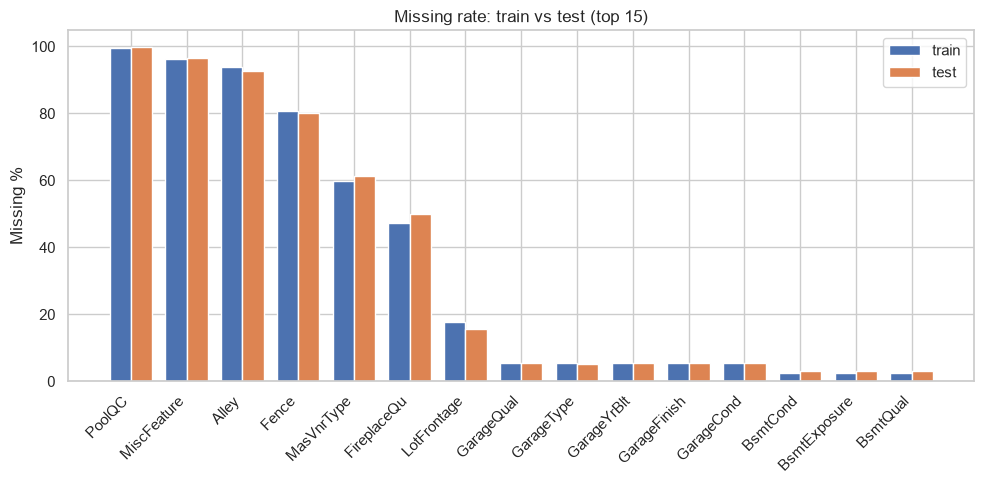

Insight: PoolQC/MiscFeature/Alley/Fence missing rất cao → thường là 'không có', nên fill 'None' thay vì drop cột ngay.


In [31]:
# Visual: top missing train vs test
top_n = missing_cmp.head(15)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(top_n))
w = 0.38
ax.bar(x - w/2, top_n["train_%"], width=w, label="train")
ax.bar(x + w/2, top_n["test_%"], width=w, label="test")
ax.set_xticks(x)
ax.set_xticklabels(top_n.index, rotation=45, ha="right")
ax.set_ylabel("Missing %")
ax.set_title("Missing rate: train vs test (top 15)")
ax.legend()
plt.tight_layout()
plt.show()

print("Insight: PoolQC/MiscFeature/Alley/Fence missing rất cao → thường là 'không có', nên fill 'None' thay vì drop cột ngay.")

### 2.2 Phân phối target `SalePrice`

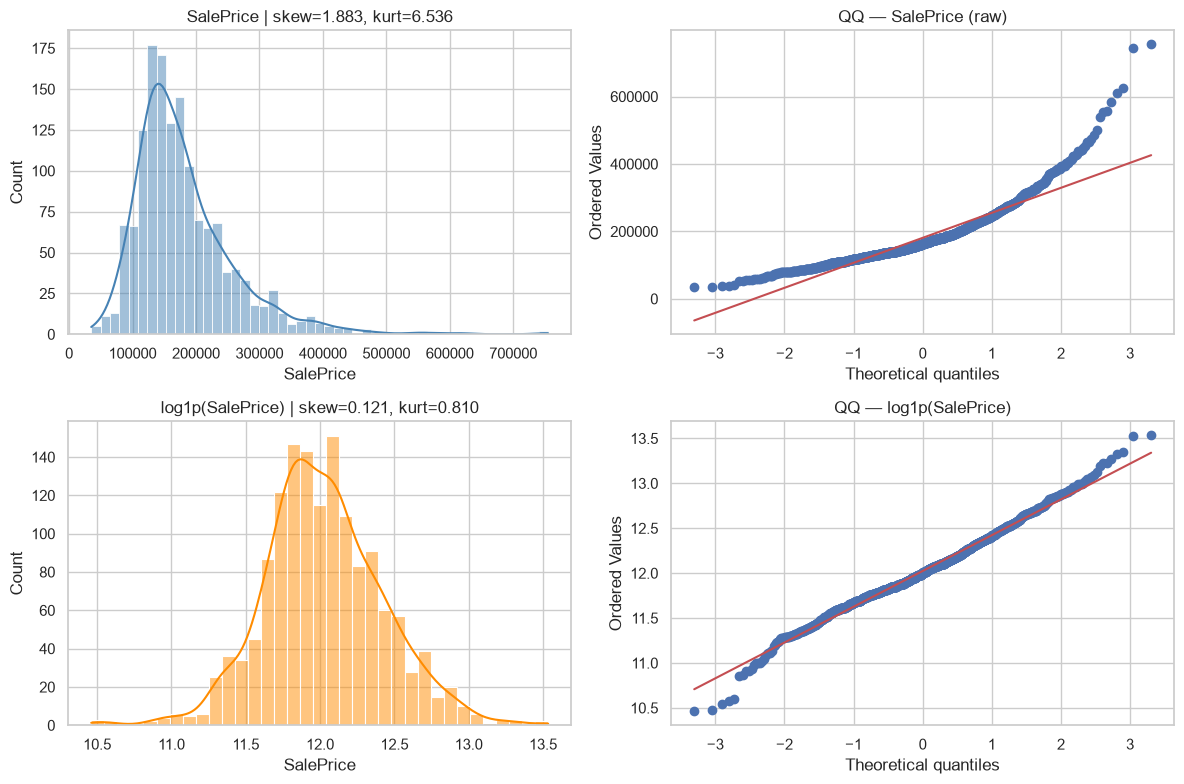

Quyết định: dùng y_log = np.log1p(y) khi train model; predict xong phải np.expm1 trước submit.


In [32]:
y_log = np.log1p(y)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Raw
sns.histplot(y, kde=True, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title(f"SalePrice | skew={y.skew():.3f}, kurt={y.kurt():.3f}")

probplot(y, plot=axes[0, 1])
axes[0, 1].set_title("QQ — SalePrice (raw)")

# Log
sns.histplot(y_log, kde=True, ax=axes[1, 0], color="darkorange")
axes[1, 0].set_title(f"log1p(SalePrice) | skew={y_log.skew():.3f}, kurt={y_log.kurt():.3f}")

probplot(y_log, plot=axes[1, 1])
axes[1, 1].set_title("QQ — log1p(SalePrice)")

plt.tight_layout()
plt.show()

print("Quyết định: dùng y_log = np.log1p(y) khi train model; predict xong phải np.expm1 trước submit.")

### 2.3 Outliers — `GrLivArea` vs `SalePrice`

Chỉ xem xét drop trên **train**. Không xóa outlier trên test.

,Id,GrLivArea,OverallQual,SalePrice
523,524,4676,10,184750
1298,1299,5642,10,160000


Số outlier ứng viên: 2


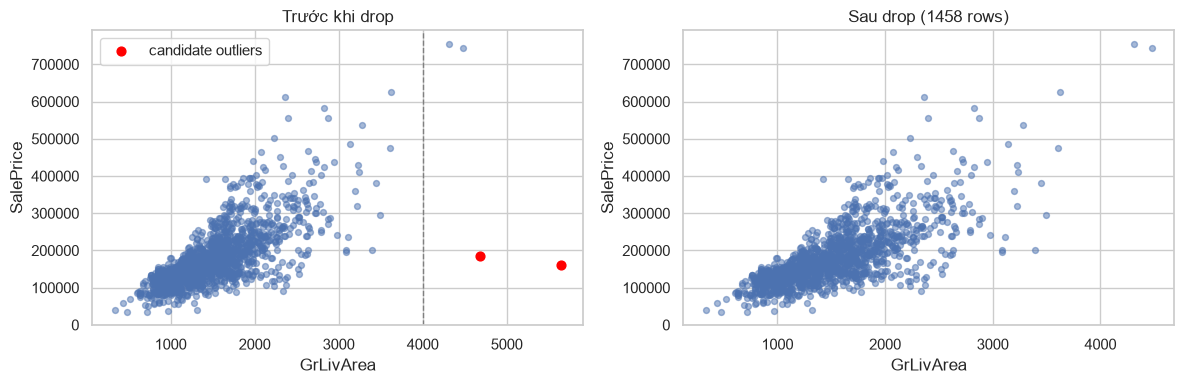

Quyết định: drop 2 điểm GrLivArea>4000 & SalePrice<300k trên train (diện tích lớn nhưng giá thấp — nhiễu cho linear/GBM).
train: 1460 → 1458 | test giữ nguyên: 1459


In [33]:
outlier_mask = (train["GrLivArea"] > 4000) & (train["SalePrice"] < 300_000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(train["GrLivArea"], train["SalePrice"], alpha=0.5, s=18)
axes[0].scatter(train.loc[outlier_mask, "GrLivArea"], train.loc[outlier_mask, "SalePrice"],
                color="red", s=40, label="candidate outliers")
axes[0].axvline(4000, color="gray", ls="--", lw=1)
axes[0].set_xlabel("GrLivArea")
axes[0].set_ylabel("SalePrice")
axes[0].set_title("Trước khi drop")
axes[0].legend()

display(train.loc[outlier_mask, ["Id", "GrLivArea", "OverallQual", "SalePrice"]])
print(f"Số outlier ứng viên: {outlier_mask.sum()}")

# Áp dụng drop trên train only (giữ biến gốc nếu cần so sánh)
train_eda = train.loc[~outlier_mask].copy()
y_eda = train_eda["SalePrice"].copy()
y_log_eda = np.log1p(y_eda)
X_train_eda = train_eda.drop(columns=["SalePrice"]).copy()

axes[1].scatter(train_eda["GrLivArea"], train_eda["SalePrice"], alpha=0.5, s=18)
axes[1].set_xlabel("GrLivArea")
axes[1].set_ylabel("SalePrice")
axes[1].set_title(f"Sau drop ({len(train_eda)} rows)")
plt.tight_layout()
plt.show()

print("Quyết định: drop 2 điểm GrLivArea>4000 & SalePrice<300k trên train (diện tích lớn nhưng giá thấp — nhiễu cho linear/GBM).")
print(f"train: {len(train)} → {len(train_eda)} | test giữ nguyên: {len(test)}")

### 2.4 Quan hệ feature–target

Top |corr| với SalePrice:


,corr_SalePrice
OverallQual,0.7958
GrLivArea,0.7350
TotalBsmtSF,0.6512
GarageCars,0.6410
1stFlrSF,0.6315
GarageArea,0.6292
FullBath,0.5622
TotRmsAbvGrd,0.5378
YearBuilt,0.5236
YearRemodAdd,0.5077


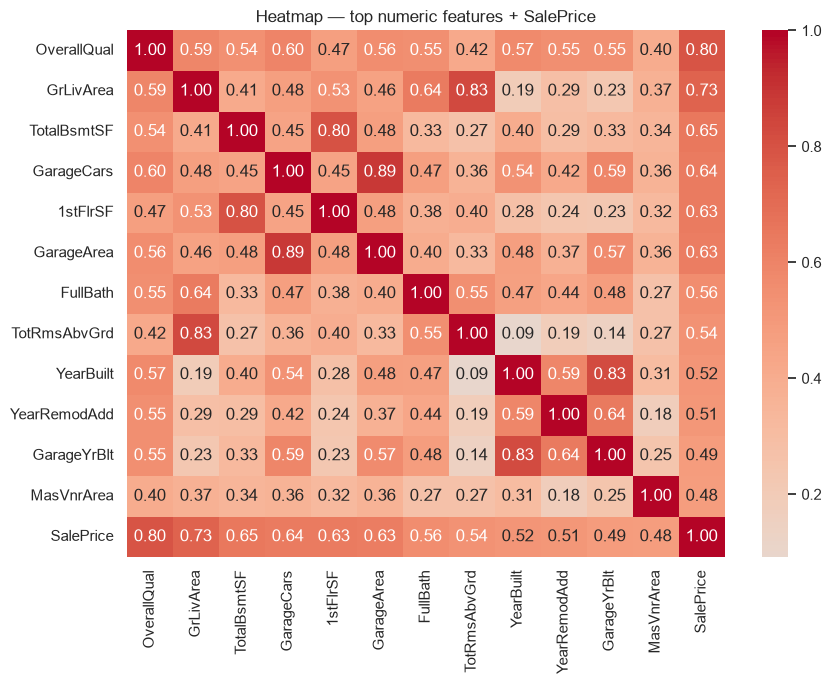

Insight: OverallQual, GrLivArea, GarageCars/Area, TotalBsmtSF, 1stFlrSF là tín hiệu mạnh.
Lưu ý đa cộng tuyến: GarageCars↔GarageArea, TotalBsmtSF↔1stFlrSF — cân nhắc TotalSF ở Phase 4.


In [34]:
# Correlation với SalePrice (numeric, full train_eda — không sample 25%)
corr_target = (
    train_eda.select_dtypes(include=["number"])
    .corr(numeric_only=True)["SalePrice"]
    .drop("SalePrice")
    .sort_values(key=np.abs, ascending=False)
)

print("Top |corr| với SalePrice:")
display(corr_target.head(20).to_frame("corr_SalePrice"))

top_feats = corr_target.head(12).index.tolist()
corr_mat = train_eda[top_feats + ["SalePrice"]].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Heatmap — top numeric features + SalePrice")
plt.tight_layout()
plt.show()

print("Insight: OverallQual, GrLivArea, GarageCars/Area, TotalBsmtSF, 1stFlrSF là tín hiệu mạnh.")
print("Lưu ý đa cộng tuyến: GarageCars↔GarageArea, TotalBsmtSF↔1stFlrSF — cân nhắc TotalSF ở Phase 4.")

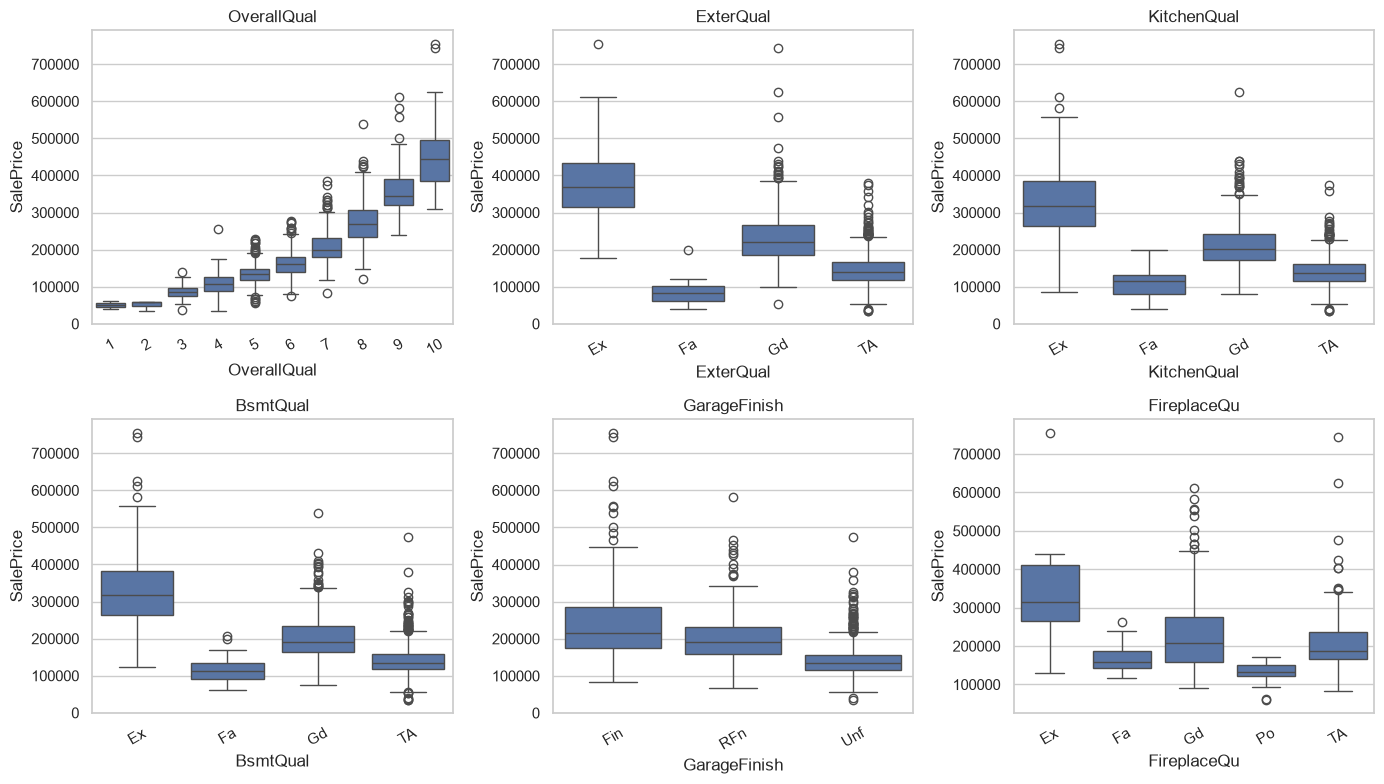

Insight: chất lượng càng cao (Ex/Gd, OverallQual cao) → SalePrice tăng rõ — phù hợp ordinal encoding.


In [35]:
# Ordinal / quality-like features
ordinal_like = ["OverallQual", "ExterQual", "KitchenQual", "BsmtQual", "GarageFinish", "FireplaceQu"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for i, col in enumerate(ordinal_like):
    order = train_eda[col].value_counts().index if train_eda[col].dtype == object else sorted(train_eda[col].dropna().unique())
    sns.boxplot(data=train_eda, x=col, y="SalePrice", order=order, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

print("Insight: chất lượng càng cao (Ex/Gd, OverallQual cao) → SalePrice tăng rõ — phù hợp ordinal encoding.")

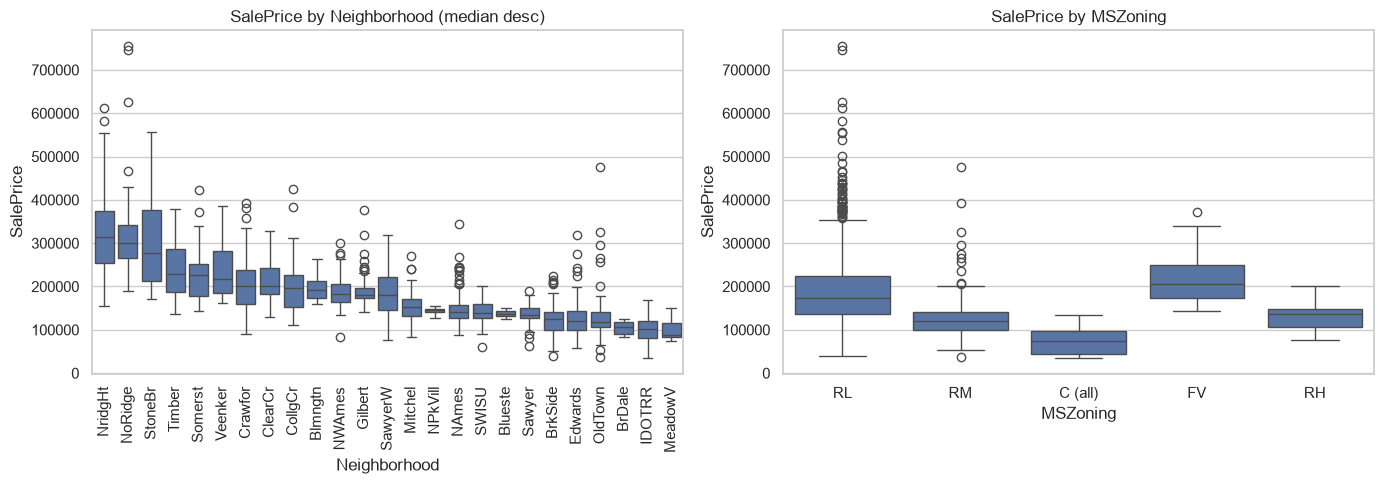

Insight: Neighborhood khác biệt mạnh → giữ làm categorical (one-hot / target-aware sau này).


In [36]:
# Categorical: Neighborhood & MSZoning — median price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nb_order = train_eda.groupby("Neighborhood")["SalePrice"].median().sort_values(ascending=False).index
sns.boxplot(data=train_eda, x="Neighborhood", y="SalePrice", order=nb_order, ax=axes[0])
axes[0].tick_params(axis="x", rotation=90)
axes[0].set_title("SalePrice by Neighborhood (median desc)")

sns.boxplot(data=train_eda, x="MSZoning", y="SalePrice", ax=axes[1])
axes[1].set_title("SalePrice by MSZoning")
plt.tight_layout()
plt.show()

print("Insight: Neighborhood khác biệt mạnh → giữ làm categorical (one-hot / target-aware sau này).")

### 2.5 Ghi chú quyết định preprocessing (cho Phase 3–5)

Quyết định rút từ EDA — Phase 3 sẽ implement theo đúng list này.

#### Imputation
| Nhóm cột | Cách fill | Lý do |
|----------|-----------|-------|
| `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu` | `"None"` | NA = không có tiện ích |
| `GarageType/Finish/Qual/Cond` | `"None"` | NA = không garage |
| `GarageYrBlt`, `GarageCars`, `GarageArea` (nếu NA) | `0` | Không garage |
| `BsmtQual/Cond/Exposure/FinType*` | `"None"` | NA = không basement |
| `Bsmt*` numeric liên quan (nếu NA trên test) | `0` | Không basement |
| `MasVnrType` | `"None"` | Thường đi kèm không veneer |
| `MasVnrArea` | `0` | |
| `LotFrontage` | **median theo `Neighborhood`** (fit train) | Tương quan theo khu |
| Còn lại categorical | mode (fit train) | Missing thật, ít |
| Còn lại numeric | median (fit train) | An toàn, chống outlier |

#### Encoding
- **Ordinal** (có thứ tự chất lượng): `ExterQual/Cond`, `BsmtQual/Cond`, `HeatingQC`, `KitchenQual`, `FireplaceQu`, `GarageQual/Cond`, `PoolQC`, `BsmtExposure`, `BsmtFinType*`, `GarageFinish`, `Functional`, `Fence`, `LandSlope`, …
- **Nominal** (one-hot, `handle_unknown='ignore'`): `MSZoning`, `Neighborhood`, `Condition*`, `HouseStyle`, `Exterior*`, `SaleType`, `SaleCondition`, …

#### Feature engineering (Phase 4)
- `TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF`
- `TotalBath = FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath`
- `Age = YrSold - YearBuilt`
- `RemodAge = YrSold - YearRemodAdd`
- Flags: `HasGarage`, `HasBsmt`, `HasPool`

#### Có thể bỏ / thận trọng
- `Id` — không dùng làm feature (nhưng giữ `test_ids` để submit)
- `Utilities` — gần như hằng trên train → cân nhắc drop
- `PoolQC` / `MiscFeature` — rất sparse; vẫn có thể giữ sau khi fill `"None"`

#### Target & outliers
- Train trên `y_log = log1p(SalePrice)`; submit bằng `expm1`
- Drop 2 outlier `GrLivArea > 4000 & SalePrice < 300000` **chỉ trên train**
- Biến dùng tiếp: `train_eda`, `X_train_eda`, `y_eda`, `y_log_eda`

### Phase 2 — Definition of Done

- [x] Tổng quan dtype + missing train vs test
- [x] Phân phối SalePrice / log1p + quyết định dùng `y_log`
- [x] Xử lý outlier `GrLivArea` trên train only
- [x] Corr numeric + boxplot ordinal/categorical có insight
- [x] Ghi chú quyết định imputation / encoding / FE

Tiếp theo → **Phase 3: Missing values & cleaning** (fit train → transform test).

## 3. Missing values & cleaning

Nguyên tắc: **fit trên train → transform train & test** (tránh leakage).

- NA mang nghĩa “không có” → `"None"` / `0`
- `LotFrontage` → median theo `Neighborhood` (học từ train)
- Còn lại: mode (cat) / median (num) — thống kê từ train
- Drop `Id` khỏi feature (đã giữ `test_ids`)
- Ordinal map + one-hot để **Phase 5**; FE để **Phase 4**

### 3.1 Helper: MissingCleaner (fit / transform)

In [37]:
class MissingCleaner:
    """Impute missing values with statistics learned from train only."""

    CAT_NONE = [
        "Alley", "MasVnrType", "BsmtQual", "BsmtCond", "BsmtExposure",
        "BsmtFinType1", "BsmtFinType2", "FireplaceQu", "GarageType",
        "GarageFinish", "GarageQual", "GarageCond", "PoolQC", "Fence",
        "MiscFeature",
    ]
    NUM_ZERO = [
        "MasVnrArea", "GarageYrBlt", "GarageArea", "GarageCars",
        "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
        "BsmtFullBath", "BsmtHalfBath",
    ]

    def __init__(self, drop_cols=None):
        self.drop_cols = list(drop_cols or ["Id"])
        self.lotfrontage_medians_ = None
        self.lotfrontage_global_ = None
        self.cat_modes_ = {}
        self.num_medians_ = {}
        self.columns_ = None

    def _apply_special(self, out: pd.DataFrame) -> pd.DataFrame:
        for c in self.CAT_NONE:
            if c in out.columns:
                out[c] = out[c].fillna("None")
        for c in self.NUM_ZERO:
            if c in out.columns:
                out[c] = out[c].fillna(0)
        if (
            self.lotfrontage_medians_ is not None
            and "LotFrontage" in out.columns
            and "Neighborhood" in out.columns
        ):
            med = self.lotfrontage_medians_
            glob = self.lotfrontage_global_
            out["LotFrontage"] = [
                (v if pd.notna(v) else med.get(nb, glob))
                for v, nb in zip(out["LotFrontage"], out["Neighborhood"])
            ]
        return out

    def fit(self, X: pd.DataFrame):
        df = X.copy()
        self.columns_ = [c for c in df.columns if c not in self.drop_cols]

        if "LotFrontage" in df.columns and "Neighborhood" in df.columns:
            self.lotfrontage_medians_ = df.groupby("Neighborhood")["LotFrontage"].median()
            self.lotfrontage_global_ = float(df["LotFrontage"].median())

        # Learn fallback stats on train AFTER special fills (covers test-only missing)
        work = self._apply_special(df[self.columns_].copy())
        self.cat_modes_ = {}
        self.num_medians_ = {}
        for c in work.columns:
            if pd.api.types.is_numeric_dtype(work[c]):
                self.num_medians_[c] = float(work[c].median())
            else:
                mode = work[c].mode(dropna=True)
                self.cat_modes_[c] = mode.iloc[0] if len(mode) else "None"
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        out = X.reindex(columns=self.columns_).copy()
        out = self._apply_special(out)

        for c, mode in self.cat_modes_.items():
            if c in out.columns:
                out[c] = out[c].fillna(mode)
        for c, med in self.num_medians_.items():
            if c in out.columns:
                out[c] = out[c].fillna(med)
        return out

    def fit_transform(self, X: pd.DataFrame) -> pd.DataFrame:
        return self.fit(X).transform(X)


print("MissingCleaner defined")


MissingCleaner defined


### 3.2 Fit trên `X_train_eda` → transform train & test

In [38]:
# Utilities gần như hằng trên train → cân nhắc drop (theo Phase 2 notes)
print("Utilities value_counts (train_eda):")
display(X_train_eda["Utilities"].value_counts(dropna=False))

cleaner = MissingCleaner(drop_cols=["Id", "Utilities"])
X_train_clean = cleaner.fit_transform(X_train_eda)
X_test_clean = cleaner.transform(X_test_raw)

print("X_train_clean:", X_train_clean.shape)
print("X_test_clean :", X_test_clean.shape)
assert list(X_train_clean.columns) == list(X_test_clean.columns)

Utilities value_counts (train_eda):


Utilities
AllPub    1457
NoSeWa       1
Name: count, dtype: int64

X_train_clean: (1458, 78)
X_test_clean : (1459, 78)


In [39]:
# Kiểm tra không còn NaN
na_train = int(X_train_clean.isna().sum().sum())
na_test = int(X_test_clean.isna().sum().sum())
print(f"NaN còn lại — train: {na_train} | test: {na_test}")

if na_train or na_test:
    print("Chi tiết train:")
    display(X_train_clean.isna().sum()[X_train_clean.isna().sum() > 0])
    print("Chi tiết test:")
    display(X_test_clean.isna().sum()[X_test_clean.isna().sum() > 0])

assert na_train == 0 and na_test == 0, "Vẫn còn missing — kiểm tra lại cleaner"

# Target gắn với train_eda (đã drop outlier)
y_clean = y_eda.copy()
y_log_clean = y_log_eda.copy()
assert len(X_train_clean) == len(y_clean) == len(y_log_clean)
print("Target sync OK:", len(y_clean), "rows")

NaN còn lại — train: 0 | test: 0
Target sync OK: 1458 rows


In [40]:
# Sanity: vài cột đã fill 'None' / 0
check_cols = ["PoolQC", "GarageType", "BsmtQual", "MasVnrType", "MasVnrArea", "GarageYrBlt", "LotFrontage"]
summary = pd.DataFrame({
    "dtype": X_train_clean[check_cols].dtypes.astype(str),
    "nunique": X_train_clean[check_cols].nunique(),
    "has_None": [(X_train_clean[c] == "None").sum() if not pd.api.types.is_numeric_dtype(X_train_clean[c]) else 0 for c in check_cols],
    "zeros": [(X_train_clean[c] == 0).sum() if pd.api.types.is_numeric_dtype(X_train_clean[c]) else 0 for c in check_cols],
}, index=check_cols)
display(summary)

display(X_train_clean.head())

,dtype,nunique,has_None,zeros
PoolQC,str,4,1452,0
GarageType,str,7,81,0
BsmtQual,str,5,37,0
MasVnrType,str,4,872,0
MasVnrArea,float64,325,0,869
GarageYrBlt,float64,98,0,81
LotFrontage,float64,115,0,0


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0000,8450,Pave,None,Reg,Lvl,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0000,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,None,Attchd,"2,003.0000",RFn,2,548,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal
1,20,RL,80.0000,9600,Pave,None,Reg,Lvl,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,"1,976.0000",RFn,2,460,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal
2,60,RL,68.0000,11250,Pave,None,IR1,Lvl,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,"2,001.0000",RFn,2,608,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal
3,70,RL,60.0000,9550,Pave,None,IR1,Lvl,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0000,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,"1,998.0000",Unf,3,642,TA,TA,Y,0,35,272,0,0,0,None,None,None,0,2,2006,WD,Abnorml
4,60,RL,84.0000,14260,Pave,None,IR1,Lvl,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0000,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,"2,000.0000",RFn,3,836,TA,TA,Y,192,84,0,0,0,0,None,None,None,0,12,2008,WD,Normal


### Phase 3 — Definition of Done

- [x] Impute không dùng `fillna(mode Series)` / `fillna(df[col]==0)`
- [x] NA “không có tiện ích” → `"None"`; numeric liên quan → `0`
- [x] `LotFrontage` median theo `Neighborhood` (fit train)
- [x] Mode/median phần còn lại học từ train
- [x] `X_train_clean` / `X_test_clean` cùng cột, **0 NaN**
- [x] `y_clean` / `y_log_clean` khớp số dòng train sau drop outlier

**Biến dùng tiếp:** `X_train_clean`, `X_test_clean`, `y_clean`, `y_log_clean`, `cleaner`

Tiếp theo → **Phase 4: Feature engineering** (`TotalSF`, `TotalBath`, `Age`, …).

## 4. Feature engineering

Tạo feature mới **deterministic** (cùng công thức train/test, không leakage).

Tối thiểu theo guide:
- `TotalSF`, `TotalBath`, `Age`, `RemodAge`
- Flags: `HasGarage`, `HasBsmt`, `HasPool`
- (thêm) `HasFireplace`, `TotalPorchSF` — hữu ích, ít rủi ro

### 4.1 FeatureEngineer

In [41]:
class FeatureEngineer:
    """Create derived features. Pure transform — no train statistics."""

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        df = X.copy()

        # Area aggregates
        df["TotalSF"] = (
            df["TotalBsmtSF"].astype(float)
            + df["1stFlrSF"].astype(float)
            + df["2ndFlrSF"].astype(float)
        )
        df["TotalPorchSF"] = (
            df["OpenPorchSF"].astype(float)
            + df["EnclosedPorch"].astype(float)
            + df["3SsnPorch"].astype(float)
            + df["ScreenPorch"].astype(float)
        )

        # Bathrooms
        df["TotalBath"] = (
            df["FullBath"].astype(float)
            + 0.5 * df["HalfBath"].astype(float)
            + df["BsmtFullBath"].astype(float)
            + 0.5 * df["BsmtHalfBath"].astype(float)
        )

        # Age-like (YrSold as reference year in dataset)
        df["Age"] = df["YrSold"].astype(float) - df["YearBuilt"].astype(float)
        df["RemodAge"] = df["YrSold"].astype(float) - df["YearRemodAdd"].astype(float)
        df["IsRemodeled"] = (df["YearBuilt"] != df["YearRemodAdd"]).astype(int)

        # Clip weird negatives (remodels before built / data glitches)
        df["Age"] = df["Age"].clip(lower=0)
        df["RemodAge"] = df["RemodAge"].clip(lower=0)

        # Presence flags
        df["HasGarage"] = (df["GarageArea"].astype(float) > 0).astype(int)
        df["HasBsmt"] = (df["TotalBsmtSF"].astype(float) > 0).astype(int)
        df["HasPool"] = (df["PoolArea"].astype(float) > 0).astype(int)
        df["HasFireplace"] = (df["Fireplaces"].astype(float) > 0).astype(int)
        df["Has2ndFlr"] = (df["2ndFlrSF"].astype(float) > 0).astype(int)

        return df

    def fit(self, X: pd.DataFrame):
        return self

    def fit_transform(self, X: pd.DataFrame) -> pd.DataFrame:
        return self.fit(X).transform(X)


print("FeatureEngineer defined")

FeatureEngineer defined


### 4.2 Áp dụng lên train & test đã clean

In [42]:
fe = FeatureEngineer()
X_train_fe = fe.fit_transform(X_train_clean)
X_test_fe = fe.transform(X_test_clean)

new_cols = [c for c in X_train_fe.columns if c not in X_train_clean.columns]
print("Feature mới:", new_cols)
print("X_train_fe:", X_train_fe.shape, "| X_test_fe:", X_test_fe.shape)
assert list(X_train_fe.columns) == list(X_test_fe.columns)
assert X_train_fe.isna().sum().sum() == 0 and X_test_fe.isna().sum().sum() == 0

Feature mới: ['TotalSF', 'TotalPorchSF', 'TotalBath', 'Age', 'RemodAge', 'IsRemodeled', 'HasGarage', 'HasBsmt', 'HasPool', 'HasFireplace', 'Has2ndFlr']
X_train_fe: (1458, 89) | X_test_fe: (1459, 89)


In [43]:
# Sanity checks: no NaN/Inf, ages non-negative
fe_num = ["TotalSF", "TotalBath", "Age", "RemodAge", "TotalPorchSF"]
display(X_train_fe[fe_num + ["HasGarage", "HasBsmt", "HasPool", "HasFireplace", "IsRemodeled"]].describe().T)

bad = []
for c in fe_num:
    if (X_train_fe[c] < 0).any() or (X_test_fe[c] < 0).any():
        bad.append(c)
    if np.isinf(X_train_fe[c]).any() or np.isinf(X_test_fe[c]).any():
        bad.append(c + "(inf)")

assert not bad, f"Feature lỗi: {bad}"
print("Sanity OK — không âm / Inf trên các feature chính")

# Nhanh: corr feature mới với target (log)
tmp = X_train_fe[new_cols].copy()
tmp["y_log"] = y_log_clean.values
corr_new = tmp.corr(numeric_only=True)["y_log"].drop("y_log").sort_values(key=np.abs, ascending=False)
print("\n|corr| với y_log (feature mới):")
display(corr_new.to_frame("corr_y_log"))

,count,mean,std,min,25%,50%,75%,max
TotalSF,"1,458.0000","2,557.1502",774.1098,334.0000,"2,008.5000","2,473.0000","3,002.2500","6,872.0000"
TotalBath,"1,458.0000",2.2075,0.7813,1.0000,2.0000,2.0000,2.5000,6.0000
Age,"1,458.0000",36.5981,30.2406,0.0000,8.0000,35.0000,54.0000,136.0000
RemodAge,"1,458.0000",22.9822,20.6365,0.0000,4.0000,14.0000,41.0000,60.0000
TotalPorchSF,"1,458.0000",86.7257,104.7924,0.0000,0.0000,48.0000,135.7500,"1,027.0000"
HasGarage,"1,458.0000",0.9444,0.2291,0.0000,1.0000,1.0000,1.0000,1.0000
HasBsmt,"1,458.0000",0.9746,0.1573,0.0000,1.0000,1.0000,1.0000,1.0000
HasPool,"1,458.0000",0.0041,0.0640,0.0000,0.0000,0.0000,0.0000,1.0000
HasFireplace,"1,458.0000",0.5267,0.4995,0.0000,0.0000,1.0000,1.0000,1.0000
IsRemodeled,"1,458.0000",0.4767,0.4996,0.0000,0.0000,0.0000,1.0000,1.0000


Sanity OK — không âm / Inf trên các feature chính

|corr| với y_log (feature mới):


,corr_y_log
TotalSF,0.8253
TotalBath,0.6767
Age,-0.5878
RemodAge,-0.5685
HasFireplace,0.5103
HasGarage,0.3230
HasBsmt,0.1996
TotalPorchSF,0.1956
Has2ndFlr,0.1506
HasPool,0.0765


### Phase 4 — Definition of Done

- [x] `TotalSF`, `TotalBath`, `Age`, `RemodAge` (+ porch / remodel flag)
- [x] Flags `HasGarage`, `HasBsmt`, `HasPool` (+ fireplace / 2nd floor)
- [x] Train & test cùng schema; không NaN/Inf; age đã clip ≥ 0

**Biến dùng tiếp:** `X_train_fe`, `X_test_fe`, `fe`  
(target vẫn: `y_clean`, `y_log_clean`)

Tiếp theo → **Phase 5: Encoding & scaling** (ordinal + one-hot, align cột).

## 5. Encoding & scaling

- **Ordinal**: map số với key khớp fill Phase 3 (`"None"`, không dùng `"NA"` lệch token)
- **Nominal**: one-hot (`handle_unknown="ignore"`), align cột train/test
- **Scale**: `RobustScaler` fit trên train → dùng cho Ridge/Lasso/ElasticNet; tree model dùng bản **unscaled**
- `MSSubClass` / `MoSold` coi là categorical

### 5.1 Ordinal maps + FeatureEncoder

In [44]:
# Ordinal maps — mọi key "None" khớp MissingCleaner
QUAL = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
EXPOSURE = {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4}
FIN_TYPE = {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6}
GARAGE_FINISH = {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3}
FUNCTIONAL = {
    "None": 0, "Sal": 1, "Sev": 2, "Maj2": 3, "Maj1": 4,
    "Mod": 5, "Min2": 6, "Min1": 7, "Typ": 8,
}
FENCE = {"None": 0, "MnWw": 1, "GdWo": 2, "MnPrv": 3, "GdPrv": 4}
SLOPE = {"Sev": 0, "Mod": 1, "Gtl": 2}
PAVED = {"N": 0, "P": 1, "Y": 2}
SHAPE = {"IR3": 0, "IR2": 1, "IR1": 2, "Reg": 3}
BINARY_STREET = {"Grvl": 0, "Pave": 1}
CENTRAL_AIR = {"N": 0, "Y": 1}

ORDINAL_MAPS = {
    "ExterQual": QUAL,
    "ExterCond": QUAL,
    "BsmtQual": QUAL,
    "BsmtCond": QUAL,
    "HeatingQC": QUAL,
    "KitchenQual": QUAL,
    "FireplaceQu": QUAL,
    "GarageQual": QUAL,
    "GarageCond": QUAL,
    "PoolQC": QUAL,
    "BsmtExposure": EXPOSURE,
    "BsmtFinType1": FIN_TYPE,
    "BsmtFinType2": FIN_TYPE,
    "GarageFinish": GARAGE_FINISH,
    "Functional": FUNCTIONAL,
    "Fence": FENCE,
    "LandSlope": SLOPE,
    "PavedDrive": PAVED,
    "LotShape": SHAPE,
    "Street": BINARY_STREET,
    "CentralAir": CENTRAL_AIR,
}

FORCE_CATEGORICAL = ["MSSubClass", "MoSold"]  # numeric masquerading as categories

print(f"Ordinal columns: {len(ORDINAL_MAPS)}")

Ordinal columns: 21


In [45]:
class FeatureEncoder:
    """Ordinal map + one-hot nominals + optional RobustScaler (fit on train)."""

    def __init__(self, ordinal_maps=None, force_categorical=None, scale=True):
        self.ordinal_maps = ordinal_maps or ORDINAL_MAPS
        self.force_categorical = list(force_categorical or FORCE_CATEGORICAL)
        self.scale = scale
        self.ohe_ = None
        self.scaler_ = None
        self.nominal_cols_ = None
        self.numeric_cols_ = None
        self.feature_names_ = None

    def _apply_ordinals(self, X: pd.DataFrame) -> pd.DataFrame:
        df = X.copy()
        for col, mapping in self.ordinal_maps.items():
            if col not in df.columns:
                continue
            df[col] = df[col].map(mapping)
            # unseen labels → 0 (neutral / None-like)
            df[col] = df[col].fillna(0).astype(float)
        return df

    def _split_cols(self, df: pd.DataFrame):
        nominal = []
        for c in df.columns:
            if c in self.ordinal_maps:
                continue
            if c in self.force_categorical:
                nominal.append(c)
            elif not pd.api.types.is_numeric_dtype(df[c]):
                nominal.append(c)
        numeric = [c for c in df.columns if c not in nominal]
        return numeric, nominal

    def fit(self, X: pd.DataFrame):
        df = self._apply_ordinals(X)
        for c in self.force_categorical:
            if c in df.columns:
                df[c] = df[c].astype(str)

        self.numeric_cols_, self.nominal_cols_ = self._split_cols(df)

        self.ohe_ = OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
            dtype=np.float64,
        )
        if self.nominal_cols_:
            self.ohe_.fit(df[self.nominal_cols_].astype(str))

        # Build a sample matrix to fit scaler / store names
        X_enc = self._encode_without_scale(df)
        self.feature_names_ = list(X_enc.columns)

        if self.scale:
            self.scaler_ = RobustScaler()
            self.scaler_.fit(X_enc.values)
        return self

    def _encode_without_scale(self, df: pd.DataFrame) -> pd.DataFrame:
        parts = [df[self.numeric_cols_].astype(float).reset_index(drop=True)]
        if self.nominal_cols_:
            ohe_arr = self.ohe_.transform(df[self.nominal_cols_].astype(str))
            ohe_cols = self.ohe_.get_feature_names_out(self.nominal_cols_)
            parts.append(pd.DataFrame(ohe_arr, columns=ohe_cols))
        out = pd.concat(parts, axis=1)
        return out

    def transform(self, X: pd.DataFrame, scale=None) -> pd.DataFrame:
        do_scale = self.scale if scale is None else scale
        df = self._apply_ordinals(X)
        for c in self.force_categorical:
            if c in df.columns:
                df[c] = df[c].astype(str)

        X_enc = self._encode_without_scale(df)
        # align to train columns (safety)
        X_enc = X_enc.reindex(columns=self.feature_names_, fill_value=0.0)

        if do_scale:
            arr = self.scaler_.transform(X_enc.values)
            return pd.DataFrame(arr, columns=self.feature_names_, index=X.index)
        return pd.DataFrame(X_enc.values, columns=self.feature_names_, index=X.index)

    def fit_transform(self, X: pd.DataFrame, scale=None) -> pd.DataFrame:
        return self.fit(X).transform(X, scale=scale)


print("FeatureEncoder defined")

FeatureEncoder defined


### 5.2 Fit trên train → transform train & test

In [47]:
encoder = FeatureEncoder(scale=True)
X_train_enc = encoder.fit_transform(X_train_fe, scale=False)   # cho tree models
X_test_enc = encoder.transform(X_test_fe, scale=False)

X_train_scaled = encoder.transform(X_train_fe, scale=True)     # cho linear models
X_test_scaled = encoder.transform(X_test_fe, scale=True)

print("numeric cols :", len(encoder.numeric_cols_))
print("nominal cols :", len(encoder.nominal_cols_))
print("X_train_enc  :", X_train_enc.shape)
print("X_test_enc   :", X_test_enc.shape)
print("X_train_scaled:", X_train_scaled.shape)

assert list(X_train_enc.columns) == list(X_test_enc.columns) == encoder.feature_names_
assert list(X_train_scaled.columns) == list(X_test_scaled.columns)
assert X_train_enc.isna().sum().sum() == 0 and X_test_enc.isna().sum().sum() == 0
assert X_train_scaled.isna().sum().sum() == 0 and X_test_scaled.isna().sum().sum() == 0
assert len(X_train_enc) == len(y_log_clean)

numeric cols : 66
nominal cols : 23
X_train_enc  : (1458, 257)
X_test_enc   : (1459, 257)
X_train_scaled: (1458, 257)


In [48]:
# Kiểm tra ordinal: không còn object ở các cột đã map; không NaN sau map
ord_cols = [c for c in ORDINAL_MAPS if c in X_train_fe.columns]
sample_ord = X_train_fe[ord_cols].copy()
for c, mapping in ORDINAL_MAPS.items():
    if c in sample_ord.columns:
        mapped = sample_ord[c].map(mapping)
        assert mapped.isna().sum() == 0, f"{c} còn label chưa map: {sample_ord.loc[mapped.isna(), c].unique()}"

print("Ordinal map OK — mọi label train đều có trong dict")
print("\nNominal (one-hot) columns:")
print(encoder.nominal_cols_)
display(X_train_enc.head())

Ordinal map OK — mọi label train đều có trong dict

Nominal (one-hot) columns:
['MSSubClass', 'MSZoning', 'Alley', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'Electrical', 'GarageType', 'MiscFeature', 'MoSold', 'SaleType', 'SaleCondition']


,LotFrontage,LotArea,Street,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,CentralAir,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,...,Heating_Floor,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,Electrical_FuseA,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,MiscFeature_Gar2,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,MoSold_1,MoSold_10,MoSold_11,MoSold_12,MoSold_2,MoSold_3,MoSold_4,MoSold_5,MoSold_6,MoSold_7,MoSold_8,MoSold_9,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,65.0000,"8,450.0000",1.0000,3.0000,2.0000,7.0000,5.0000,"2,003.0000","2,003.0000",196.0000,4.0000,3.0000,4.0000,3.0000,1.0000,6.0000,706.0000,1.0000,0.0000,150.0000,856.0000,5.0000,1.0000,856.0000,854.0000,0.0000,"1,710.0000",1.0000,0.0000,2.0000,1.0000,3.0000,1.0000,4.0000,8.0000,8.0000,0.0000,0.0000,"2,003.0000",2.0000,2.0000,548.0000,3.0000,3.0000,2.0000,0.0000,61.0000,0.0000,0.0000,0.0000,...,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
1,80.0000,"9,600.0000",1.0000,3.0000,2.0000,6.0000,8.0000,"1,976.0000","1,976.0000",0.0000,3.0000,3.0000,4.0000,3.0000,4.0000,5.0000,978.0000,1.0000,0.0000,284.0000,"1,262.0000",5.0000,1.0000,"1,262.0000",0.0000,0.0000,"1,262.0000",0.0000,1.0000,2.0000,0.0000,3.0000,1.0000,3.0000,6.0000,8.0000,1.0000,3.0000,"1,976.0000",2.0000,2.0000,460.0000,3.0000,3.0000,2.0000,298.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
2,68.0000,"11,250.0000",1.0000,2.0000,2.0000,7.0000,5.0000,"2,001.0000","2,002.0000",162.0000,4.0000,3.0000,4.0000,3.0000,2.0000,6.0000,486.0000,1.0000,0.0000,434.0000,920.0000,5.0000,1.0000,920.0000,866.0000,0.0000,"1,786.0000",1.0000,0.0000,2.0000,1.0000,3.0000,1.0000,4.0000,6.0000,8.0000,1.0000,3.0000,"2,001.0000",2.0000,2.0000,608.0000,3.0000,3.0000,2.0000,0.0000,42.0000,0.0000,0.0000,0.0000,...,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
3,60.0000,"9,550.0000",1.0000,2.0000,2.0000,7.0000,5.0000,"1,915.0000","1,970.0000",0.0000,3.0000,3.0000,3.0000,4.0000,1.0000,5.0000,216.0000,1.0000,0.0000,540.0000,756.0000,4.0000,1.0000,961.0000,756.0000,0.0000,"1,717.0000",1.0000,0.0000,1.0000,0.0000,3.0000,1.0000,4.0000,7.0000,8.0000,1.0000,4.0000,"1,998.0000",1.0000,3.0000,642.0000,3.0000,3.0000,2.0000,0.0000,35.0000,272.0000,0.0000,0.0000,...,0.0000,1.0000,0.0000,0.0000,0.0000,0.000

### Phase 5 — Definition of Done

- [x] Ordinal map dùng key `"None"` khớp Phase 3
- [x] One-hot nominal + `handle_unknown="ignore"`; train/test cùng cột
- [x] `RobustScaler` fit train → `X_*_scaled` cho linear
- [x] Bản `X_*_enc` (unscaled) cho RandomForest / GBM
- [x] 0 NaN; số dòng khớp `y_log_clean`

**Biến dùng tiếp:**
- Tree: `X_train_enc`, `X_test_enc`
- Linear: `X_train_scaled`, `X_test_scaled`
- Target: `y_clean`, `y_log_clean`
- Objects: `encoder`

Tiếp theo → **Phase 6: Model training & validation** (CV + RMSLE).

## 6. Model training & validation

- Train trên `log1p(SalePrice)`; score bằng **RMSLE** trên thang giá gốc (`expm1` rồi so sánh)
- CV **5-fold**: mỗi fold **fit lại** `MissingCleaner` → `FeatureEngineer` → `FeatureEncoder` trên fold-train (tránh leakage)
- So sánh: median baseline → Ridge/Lasso/ElasticNet → RandomForest → GradientBoosting
- Chọn model tốt nhất theo CV mean RMSLE cho Phase 7

### 6.1 Metric & CV helper

In [49]:
def rmsle(y_true, y_pred):
    """RMSLE trên thang giá gốc."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(
        np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(np.clip(y_pred, 0, None))))
    )


def make_xy_fold(X_raw: pd.DataFrame, y: pd.Series, train_idx, val_idx, scale: bool):
    """Fit preprocess trên fold-train, transform train/val."""
    X_tr_raw, X_va_raw = X_raw.iloc[train_idx].copy(), X_raw.iloc[val_idx].copy()
    y_tr, y_va = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

    cleaner = MissingCleaner(drop_cols=["Id", "Utilities"])
    X_tr = cleaner.fit_transform(X_tr_raw)
    X_va = cleaner.transform(X_va_raw)

    fe = FeatureEngineer()
    X_tr = fe.fit_transform(X_tr)
    X_va = fe.transform(X_va)

    enc = FeatureEncoder(scale=True)
    enc.fit(X_tr)
    X_tr_m = enc.transform(X_tr, scale=scale)
    X_va_m = enc.transform(X_va, scale=scale)
    return X_tr_m, X_va_m, y_tr, y_va


def cv_rmsle(model, X_raw: pd.DataFrame, y: pd.Series, scale: bool, n_splits: int = 5, seed: int = RANDOM_STATE):
    """KFold RMSLE; model được clone logic bằng re-fit mỗi fold (truyền estimator mới? dùng clone)."""
    from sklearn.base import clone

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    scores = []
    for fold, (tr_idx, va_idx) in enumerate(kf.split(X_raw), start=1):
        X_tr, X_va, y_tr, y_va = make_xy_fold(X_raw, y, tr_idx, va_idx, scale=scale)
        m = clone(model)
        m.fit(X_tr.values, np.log1p(y_tr.values))
        pred = np.expm1(m.predict(X_va.values))
        score = rmsle(y_va.values, pred)
        scores.append(score)
        print(f"  fold {fold}: {score:.5f}")
    scores = np.asarray(scores, dtype=float)
    return float(scores.mean()), float(scores.std()), scores


print("rmsle / cv helpers ready")

rmsle / cv helpers ready


### 6.2 Baseline

In [50]:
# Dùng X_train_eda + y_clean (đã drop outlier, chưa encode — preprocess trong từng fold)
X_cv = X_train_eda.reset_index(drop=True)
y_cv = y_clean.reset_index(drop=True)
assert len(X_cv) == len(y_cv)

# Baseline 1: median SalePrice (không học feature)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
median_scores = []
for tr_idx, va_idx in kf.split(X_cv):
    y_tr, y_va = y_cv.iloc[tr_idx], y_cv.iloc[va_idx]
    pred = np.full(len(y_va), y_tr.median())
    median_scores.append(rmsle(y_va.values, pred))
median_scores = np.asarray(median_scores)
print(f"Median baseline CV RMSLE: {median_scores.mean():.5f} ± {median_scores.std():.5f}")

results = []
results.append({
    "model": "MedianBaseline",
    "cv_rmsle_mean": median_scores.mean(),
    "cv_rmsle_std": median_scores.std(),
    "scale": False,
    "notes": "predict = median(y_train_fold)",
})

Median baseline CV RMSLE: 0.39994 ± 0.01680


In [51]:
# Baseline 2: Ridge trên vài feature mạnh (sau FE trong fold — dùng full pipeline + Ridge nhẹ)
print("Ridge (alpha=10) — full pipeline CV")
mean, std, _ = cv_rmsle(Ridge(alpha=10.0, random_state=RANDOM_STATE), X_cv, y_cv, scale=True)
results.append({
    "model": "Ridge(alpha=10)",
    "cv_rmsle_mean": mean,
    "cv_rmsle_std": std,
    "scale": True,
    "notes": "linear baseline, scaled",
})
print(f"=> {mean:.5f} ± {std:.5f}")

Ridge (alpha=10) — full pipeline CV
  fold 1: 0.12036
  fold 2: 0.11189
  fold 3: 0.11800
  fold 4: 0.11966
  fold 5: 0.10008
=> 0.11400 ± 0.00757


### 6.3 Linear models (scaled)

In [52]:
linear_models = {
    "Ridge(alpha=1)": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Ridge(alpha=10)": Ridge(alpha=10.0, random_state=RANDOM_STATE),
    "Lasso(alpha=0.0005)": Lasso(alpha=0.0005, max_iter=10000, random_state=RANDOM_STATE),
    "ElasticNet(0.0005,0.5)": ElasticNet(alpha=0.0005, l1_ratio=0.5, max_iter=10000, random_state=RANDOM_STATE),
}

# Ridge(alpha=10) đã chạy ở baseline — bỏ qua nếu trùng tên đã có
done = {r["model"] for r in results}

for name, model in linear_models.items():
    if name in done:
        print(f"\nSkip {name} (already in results)")
        continue
    print(f"\n=== {name} ===")
    mean, std, _ = cv_rmsle(model, X_cv, y_cv, scale=True)
    results.append({
        "model": name,
        "cv_rmsle_mean": mean,
        "cv_rmsle_std": std,
        "scale": True,
        "notes": "linear + RobustScaler",
    })
    print(f"=> {mean:.5f} ± {std:.5f}")


=== Ridge(alpha=1) ===
  fold 1: 0.12237
  fold 2: 0.12345
  fold 3: 0.12077
  fold 4: 0.12529
  fold 5: 0.10475
=> 0.11933 ± 0.00743

Skip Ridge(alpha=10) (already in results)

=== Lasso(alpha=0.0005) ===
  fold 1: 0.11462
  fold 2: 0.11141
  fold 3: 0.11770
  fold 4: 0.11482
  fold 5: 0.10089
=> 0.11189 ± 0.00585

=== ElasticNet(0.0005,0.5) ===
  fold 1: 0.11551
  fold 2: 0.11348
  fold 3: 0.11734
  fold 4: 0.11696
  fold 5: 0.10156
=> 0.11297 ± 0.00586


### 6.4 Tree models (unscaled)

In [53]:
tree_models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE,
    ),
}

for name, model in tree_models.items():
    print(f"\n=== {name} ===")
    mean, std, _ = cv_rmsle(model, X_cv, y_cv, scale=False)
    results.append({
        "model": name,
        "cv_rmsle_mean": mean,
        "cv_rmsle_std": std,
        "scale": False,
        "notes": "tree on encoded features (no scaler)",
    })
    print(f"=> {mean:.5f} ± {std:.5f}")


=== RandomForest ===
  fold 1: 0.14212
  fold 2: 0.12854
  fold 3: 0.14005
  fold 4: 0.13761
  fold 5: 0.12659
=> 0.13498 ± 0.00625

=== GradientBoosting ===
  fold 1: 0.11750
  fold 2: 0.11725
  fold 3: 0.12048
  fold 4: 0.13140
  fold 5: 0.11763
=> 0.12085 ± 0.00540


### 6.5 Bảng kết quả & chọn model

In [54]:
results_df = pd.DataFrame(results).sort_values("cv_rmsle_mean").reset_index(drop=True)
display(results_df)

best_row = results_df.iloc[0]
print(
    f"Best: {best_row['model']} | CV RMSLE = {best_row['cv_rmsle_mean']:.5f} ± {best_row['cv_rmsle_std']:.5f}"
)

# Estimator factory cho Phase 7
MODEL_ZOO = {
    "MedianBaseline": None,
    "Ridge(alpha=1)": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Ridge(alpha=10)": Ridge(alpha=10.0, random_state=RANDOM_STATE),
    "Lasso(alpha=0.0005)": Lasso(alpha=0.0005, max_iter=10000, random_state=RANDOM_STATE),
    "ElasticNet(0.0005,0.5)": ElasticNet(alpha=0.0005, l1_ratio=0.5, max_iter=10000, random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(
        n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE
    ),
}

best_model_name = best_row["model"]
best_use_scale = bool(best_row["scale"])
best_estimator = MODEL_ZOO[best_model_name]
assert best_estimator is not None, "MedianBaseline không dùng để submit — chọn model học được"
print("Ready for Phase 7:", best_model_name, "| scale=", best_use_scale)

,model,cv_rmsle_mean,cv_rmsle_std,scale,notes
0,Lasso(alpha=0.0005),0.1119,0.0058,True,linear + RobustScaler
1,"ElasticNet(0.0005,0.5)",0.1130,0.0059,True,linear + RobustScaler
2,Ridge(alpha=10),0.1140,0.0076,True,"linear baseline, scaled"
3,Ridge(alpha=1),0.1193,0.0074,True,linear + RobustScaler
4,GradientBoosting,0.1209,0.0054,False,tree on encoded features (no scaler)
5,RandomForest,0.1350,0.0063,False,tree on encoded features (no scaler)
6,MedianBaseline,0.3999,0.0168,False,predict = median(y_train_fold)


Best: Lasso(alpha=0.0005) | CV RMSLE = 0.11189 ± 0.00585
Ready for Phase 7: Lasso(alpha=0.0005) | scale= True


### Phase 6 — Definition of Done

- [x] `rmsle` + CV 5-fold với preprocess fit trong từng fold
- [x] Median baseline + Ridge baseline
- [x] Linear (Ridge/Lasso/ElasticNet) + Tree (RF/GBM)
- [x] Bảng `results_df` + chọn `best_model_name` / `best_estimator`

**Biến dùng tiếp:** `best_model_name`, `best_estimator`, `best_use_scale`, `results_df`, `X_cv`, `y_cv`

Tiếp theo → **Phase 7: Predict test + `submission.csv`**.

## 7. Predict test + submission

1. Fit lại preprocess + **best model** trên **toàn bộ** train (sau drop outlier)
2. Predict Kaggle `test` → `expm1` về thang giá gốc
3. Xuất `submission.csv` (`Id`, `SalePrice`)
4. Sanity check phân phối / NaN / Inf

### 7.1 Fit full-train pipeline + best model

In [55]:
from sklearn.base import clone

assert "best_estimator" in dir() and best_estimator is not None, "Chạy Phase 6 trước để có best_estimator"
assert "best_model_name" in dir() and "best_use_scale" in dir()

print(f"Submitting with: {best_model_name} | scale={best_use_scale}")
print(f"CV RMSLE (from Phase 6): {results_df.iloc[0]['cv_rmsle_mean']:.5f} ± {results_df.iloc[0]['cv_rmsle_std']:.5f}")

# Full-train preprocess (cùng công thức CV, nhưng fit trên toàn bộ X_train_eda)
final_cleaner = MissingCleaner(drop_cols=["Id", "Utilities"])
X_tr_full = final_cleaner.fit_transform(X_train_eda)
X_te_full = final_cleaner.transform(X_test_raw)

final_fe = FeatureEngineer()
X_tr_full = final_fe.fit_transform(X_tr_full)
X_te_full = final_fe.transform(X_te_full)

final_encoder = FeatureEncoder(scale=True)
final_encoder.fit(X_tr_full)
X_tr_model = final_encoder.transform(X_tr_full, scale=best_use_scale)
X_te_model = final_encoder.transform(X_te_full, scale=best_use_scale)

print("X_tr_model:", X_tr_model.shape, "| X_te_model:", X_te_model.shape)
assert list(X_tr_model.columns) == list(X_te_model.columns)

final_model = clone(best_estimator)
final_model.fit(X_tr_model.values, np.log1p(y_clean.values))
print("Final model fitted on full train:", len(y_clean), "rows")

Submitting with: Lasso(alpha=0.0005) | scale=True
CV RMSLE (from Phase 6): 0.11189 ± 0.00585
X_tr_model: (1458, 257) | X_te_model: (1459, 257)
Final model fitted on full train: 1458 rows


### 7.2 Predict test & sanity checks

pred_prices describe:


count       1,459.0000
mean      179,033.4426
std        86,303.0768
min        40,053.1469
25%       125,795.6630
50%       157,335.3248
75%       211,284.7869
max     1,701,556.7013
Name: SalePrice, dtype: float64

,train_SalePrice,pred_SalePrice
count,"1,458.0000","1,459.0000"
mean,"180,932.9191","179,033.4426"
std,"79,495.0553","86,303.0768"
min,"34,900.0000","40,053.1469"
25%,"129,925.0000","125,795.6630"
50%,"163,000.0000","157,335.3248"
75%,"214,000.0000","211,284.7869"
max,"755,000.0000","1,701,556.7013"


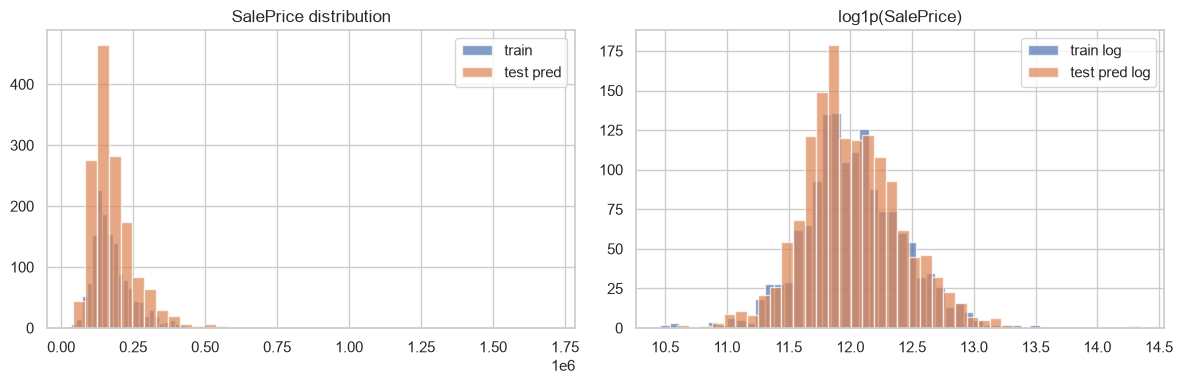

Sanity OK


In [56]:
pred_log = final_model.predict(X_te_model.values)
pred_prices = np.expm1(pred_log)

print("pred_prices describe:")
display(pd.Series(pred_prices, name="SalePrice").describe())

# So với phân phối train
cmp = pd.DataFrame({
    "train_SalePrice": y_clean.describe(),
    "pred_SalePrice": pd.Series(pred_prices).describe(),
})
display(cmp)

assert len(pred_prices) == len(test_ids) == 1459
assert np.isfinite(pred_prices).all(), "Pred có NaN/Inf"
assert (pred_prices > 0).all(), "Pred có giá ≤ 0"

# Phân phối nhanh
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_clean, bins=40, alpha=0.7, label="train")
axes[0].hist(pred_prices, bins=40, alpha=0.7, label="test pred")
axes[0].set_title("SalePrice distribution")
axes[0].legend()
axes[1].hist(np.log1p(y_clean), bins=40, alpha=0.7, label="train log")
axes[1].hist(pred_log, bins=40, alpha=0.7, label="test pred log")
axes[1].set_title("log1p(SalePrice)")
axes[1].legend()
plt.tight_layout()
plt.show()

print("Sanity OK")

### 7.3 Xuất `submission.csv`

In [57]:
submission = pd.DataFrame({
    "Id": test_ids.values,
    "SalePrice": pred_prices,
})

assert list(submission.columns) == ["Id", "SalePrice"]
assert len(submission) == 1459
assert submission["Id"].tolist() == test["Id"].tolist()

out_path = DATA_DIR / "submission.csv"
submission.to_csv(out_path, index=False)
print(f"Wrote {out_path.resolve()}")
display(submission.head())
display(submission.tail())

Wrote /Users/fuwhis/Downloads/VEF_DA_FinalProject/submission.csv


,Id,SalePrice
0,1461,"118,176.1579"
1,1462,"151,471.6053"
2,1463,"175,716.2592"
3,1464,"199,536.5947"
4,1465,"192,897.1821"


,Id,SalePrice
1454,2915,"86,708.5463"
1455,2916,"83,065.1471"
1456,2917,"167,160.1030"
1457,2918,"116,834.5988"
1458,2919,"228,233.2864"


In [58]:
# Nhật ký thí nghiệm (điền public LB sau khi nộp Kaggle)
experiment_log = {
    "date": pd.Timestamp.today().strftime("%Y-%m-%d"),
    "model": best_model_name,
    "scale": best_use_scale,
    "cv_rmsle_mean": float(results_df.iloc[0]["cv_rmsle_mean"]),
    "cv_rmsle_std": float(results_df.iloc[0]["cv_rmsle_std"]),
    "train_rows": int(len(y_clean)),
    "n_features": int(X_tr_model.shape[1]),
    "submission_path": str(out_path),
    "public_lb": None,  # điền sau khi submit
}
display(pd.Series(experiment_log, name="experiment"))
print("Nhớ cập nhật public_lb sau khi nộp lên Kaggle.")

date                        2026-08-16
model              Lasso(alpha=0.0005)
scale                             True
cv_rmsle_mean                   0.1119
cv_rmsle_std                    0.0058
train_rows                        1458
n_features                         257
submission_path         submission.csv
public_lb                         None
Name: experiment, dtype: object

Nhớ cập nhật public_lb sau khi nộp lên Kaggle.


### Phase 7 — Definition of Done

- [x] Fit preprocess + best model trên full train
- [x] Predict test → `expm1` → giá gốc
- [x] Sanity: 1459 dòng, `Id` khớp, không NaN/Inf/âm
- [x] File `submission.csv` sẵn sàng nộp Kaggle
- [ ] (Bạn) Nộp Kaggle + ghi public LB vào `experiment_log`

Tiếp theo (optional) → **Phase 8: Error analysis**.

## 8. (Optional) Error analysis & next experiments

> TODO Phase 8: residual plots, feature importance, ý tưởng cải thiện tiếp.

In [ ]:
# TODO Phase 8
pass